# Fatigue Feature Dataset Generation

This notebook converts raw `drowsy` and `alert` face images into a structured CSV dataset for machine-learning training.

Pipeline:

`Images -> MediaPipe FaceMesh -> facial landmarks -> EAR, MAR, head pitch -> CSV`

The notebook intentionally uses lightweight, interpretable feature engineering. It does not use CNNs or deep learning.

## 1. Imports and Configuration

In [11]:
from pathlib import Path
import math
from typing import Dict, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
from tqdm import tqdm

In [12]:
# Paths are relative to the project root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_CSV_PATH = PROCESSED_DATA_DIR / "fatigue_features.csv"

# Output labels stay exactly as required for ML training.
# The alert class accepts both folder names because this repo currently uses data/raw/non_drowsy.
CLASS_FOLDERS = {
    "drowsy": ["drowsy"],
    "alert": ["alert", "non_drowsy"],
}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# MediaPipe landmark indices used by the feature extractors.
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]
MOUTH = [61, 81, 13, 291, 311, 14]

NOSE_TIP = 1
CHIN = 152
LEFT_EYE_OUTER = 33
RIGHT_EYE_OUTER = 263

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Output CSV path: {OUTPUT_CSV_PATH}")

Project root: c:\Users\chari\Desktop\AI_Powered_Fatigue_Detection
Raw data directory: c:\Users\chari\Desktop\AI_Powered_Fatigue_Detection\data\raw
Output CSV path: c:\Users\chari\Desktop\AI_Powered_Fatigue_Detection\data\processed\fatigue_features.csv


## 2. Utility Functions

In [13]:
def collect_image_paths(raw_data_dir: Path, class_folders: Dict[str, List[str]]) -> List[Tuple[Path, str]]:
    """Recursively collect image paths and map folders to final class labels."""
    image_paths = []

    for label, folder_names in class_folders.items():
        found_any_folder = False

        for folder_name in folder_names:
            class_dir = raw_data_dir / folder_name

            if not class_dir.exists():
                continue

            found_any_folder = True
            for image_path in class_dir.rglob("*"):
                if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                    image_paths.append((image_path, label))

        if not found_any_folder:
            expected_dirs = [str(raw_data_dir / folder_name) for folder_name in folder_names]
            print(f"Warning: missing class directory for label '{label}': {expected_dirs}")

    return sorted(image_paths, key=lambda item: str(item[0]))


def load_image_bgr(image_path: Path) -> Optional[np.ndarray]:
    """Load an image with OpenCV. Returns None for unreadable or corrupted files."""
    image = cv2.imread(str(image_path))

    if image is None or image.size == 0:
        return None

    return image


def normalized_landmarks_to_pixels(landmarks, image_shape: Tuple[int, int, int]) -> np.ndarray:
    """Convert MediaPipe normalized landmarks to pixel coordinates."""
    height, width = image_shape[:2]

    points = []
    for landmark in landmarks.landmark:
        points.append((landmark.x * width, landmark.y * height, landmark.z))

    return np.array(points, dtype=np.float32)


def euclidean_distance(point_a: np.ndarray, point_b: np.ndarray) -> float:
    """Compute 2D Euclidean distance between two facial landmark points."""
    return float(np.linalg.norm(point_a[:2] - point_b[:2]))

## 3. Feature Extraction Functions

In [14]:
def calculate_aspect_ratio(points: np.ndarray, landmark_indices: List[int]) -> float:
    """Calculate an eye-like aspect ratio from six ordered landmarks."""
    p1, p2, p3, p4, p5, p6 = [points[index] for index in landmark_indices]

    vertical_distance_1 = euclidean_distance(p2, p6)
    vertical_distance_2 = euclidean_distance(p3, p5)
    horizontal_distance = euclidean_distance(p1, p4)

    if horizontal_distance == 0:
        return np.nan

    return (vertical_distance_1 + vertical_distance_2) / (2.0 * horizontal_distance)


def calculate_ear(points: np.ndarray) -> float:
    """Calculate average Eye Aspect Ratio across left and right eyes."""
    left_ear = calculate_aspect_ratio(points, LEFT_EYE)
    right_ear = calculate_aspect_ratio(points, RIGHT_EYE)

    return float(np.nanmean([left_ear, right_ear]))


def calculate_mar(points: np.ndarray) -> float:
    """Calculate Mouth Aspect Ratio using selected lip landmarks."""
    return float(calculate_aspect_ratio(points, MOUTH))


def estimate_head_pitch(points: np.ndarray) -> float:
    """Estimate head pitch with a simple 2D landmark proxy.

    This is not a camera-calibrated 3D pose estimate. It measures how far the
    nose tip sits vertically between the eye line and chin, then converts that
    normalized displacement into an interpretable angle-like value.

    Positive values usually indicate the head is tilted downward. Negative
    values usually indicate the head is tilted upward. For production use,
    calibrate the neutral ratio on a small set of front-facing alert images.
    """
    left_eye = points[LEFT_EYE_OUTER]
    right_eye = points[RIGHT_EYE_OUTER]
    eye_midpoint = (left_eye + right_eye) / 2.0

    nose_tip = points[NOSE_TIP]
    chin = points[CHIN]

    face_height = euclidean_distance(eye_midpoint, chin)
    if face_height == 0:
        return np.nan

    nose_vertical_ratio = (nose_tip[1] - eye_midpoint[1]) / face_height

    # A rough neutral reference for front-facing faces. Tune this later if needed.
    neutral_ratio = 0.35
    pitch_radians = math.atan(nose_vertical_ratio - neutral_ratio)

    return float(math.degrees(pitch_radians))

## 4. Single Image Processing

In [15]:
def extract_features_from_image(
    image_path: Path,
    label: str,
    face_mesh,
) -> Tuple[Optional[Dict[str, object]], Optional[Dict[str, object]]]:
    """Extract EAR, MAR, and head pitch from one image.

    Returns:
        feature_row: Dictionary for the final CSV, or None if extraction fails.
        failure_row: Dictionary describing the failure, or None on success.
    """
    image_bgr = load_image_bgr(image_path)
    if image_bgr is None:
        return None, {
            "image_name": image_path.name,
            "image_path": str(image_path),
            "label": label,
            "reason": "unreadable_or_corrupted_image",
        }

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(image_rgb)

    detected_faces = results.multi_face_landmarks or []
    face_count = len(detected_faces)

    if face_count == 0:
        return None, {
            "image_name": image_path.name,
            "image_path": str(image_path),
            "label": label,
            "reason": "no_face_detected",
        }

    if face_count > 1:
        return None, {
            "image_name": image_path.name,
            "image_path": str(image_path),
            "label": label,
            "reason": "multiple_faces_detected",
        }

    points = normalized_landmarks_to_pixels(detected_faces[0], image_bgr.shape)

    ear = calculate_ear(points)
    mar = calculate_mar(points)
    head_pitch = estimate_head_pitch(points)

    if not np.isfinite([ear, mar, head_pitch]).all():
        return None, {
            "image_name": image_path.name,
            "image_path": str(image_path),
            "label": label,
            "reason": "invalid_feature_value",
        }

    feature_row = {
        "image_name": image_path.name,
        "EAR": ear,
        "MAR": mar,
        "head_pitch": head_pitch,
        "label": label,
    }

    return feature_row, None

## 5. Process the Full Dataset

In [16]:
image_label_pairs = collect_image_paths(RAW_DATA_DIR, CLASS_FOLDERS)

print(f"Total images found: {len(image_label_pairs)}")
print(pd.Series([label for _, label in image_label_pairs]).value_counts())

Exception ignored in: <function tqdm.__del__ at 0x0000014C5C358160>
Traceback (most recent call last):
  File "c:\Users\chari\Desktop\AI_Powered_Fatigue_Detection\venv\lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\chari\Desktop\AI_Powered_Fatigue_Detection\venv\lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


Total images found: 46343
drowsy    25258
alert     21085
Name: count, dtype: int64


In [17]:
mp_face_mesh = mp.solutions.face_mesh

feature_rows = []
failure_rows = []

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=2,
    refine_landmarks=True,
    min_detection_confidence=0.5,
) as face_mesh:
    for image_path, label in tqdm(image_label_pairs, desc="Extracting fatigue features"):
        feature_row, failure_row = extract_features_from_image(image_path, label, face_mesh)

        if feature_row is not None:
            feature_rows.append(feature_row)

        if failure_row is not None:
            failure_rows.append(failure_row)

features_df = pd.DataFrame(feature_rows, columns=["image_name", "EAR", "MAR", "head_pitch", "label"])
failures_df = pd.DataFrame(failure_rows)

print("Processing statistics")
print(f"Total images: {len(image_label_pairs)}")
print(f"Successful extractions: {len(features_df)}")
print(f"Failed images: {len(failures_df)}")

if not failures_df.empty:
    print("\nFailure reasons:")
    print(failures_df["reason"].value_counts())

Extracting fatigue features:   0%|          | 0/46343 [00:00<?, ?it/s]

Extracting fatigue features: 100%|██████████| 46343/46343 [16:15<00:00, 47.50it/s]

Processing statistics
Total images: 46343
Successful extractions: 45746
Failed images: 597

Failure reasons:
reason
no_face_detected           541
multiple_faces_detected     56
Name: count, dtype: int64


## 6. Save the Feature CSV

In [18]:
features_df.to_csv(OUTPUT_CSV_PATH, index=False)

print(f"Saved feature dataset to: {OUTPUT_CSV_PATH}")
features_df.head()

Saved feature dataset to: c:\Users\chari\Desktop\AI_Powered_Fatigue_Detection\data\processed\fatigue_features.csv


,image_name,EAR,MAR,head_pitch,label
0,1.png,0.181018,0.221612,-8.669280,drowsy
1,10.jpg_0.png,0.215475,0.292669,-1.428185,drowsy
2,10.png,0.190481,0.226371,-6.025446,drowsy
3,100.jpg_0.png,0.252700,0.320923,-0.756178,drowsy
4,100.png,0.264408,0.221572,-3.036699,drowsy


## 7. Dataset Summary

In [19]:
print("Dataset shape:", features_df.shape)
print("\nClass distribution:")
print(features_df["label"].value_counts())

features_df[["EAR", "MAR", "head_pitch"]].describe()

Dataset shape: (45746, 5)

Class distribution:
label
drowsy    24790
alert     20956
Name: count, dtype: int64


,EAR,MAR,head_pitch
count,45746.000000,45746.000000,45746.000000
mean,0.237517,0.230678,-2.273623
std,0.080527,0.023297,4.669028
min,0.011247,0.184806,-30.620708
25%,0.200009,0.224110,-5.278641
50%,0.236055,0.226944,-2.063289
75%,0.280841,0.230112,0.793680
max,0.549551,0.613525,14.663391


In [20]:
features_df.groupby("label")[["EAR", "MAR", "head_pitch"]].agg(["mean", "std", "min", "max"])

EAR                                     MAR                      \
            mean       std       min       max      mean       std       min   
label                                                                          
alert   0.270576  0.062762  0.022022  0.549551  0.227228  0.006648  0.184806   
drowsy  0.209571  0.083257  0.011247  0.533419  0.233595  0.030751  0.187894   

                 head_pitch                                  
             max       mean       std        min        max  
label                                                        
alert   0.381241  -2.243976  4.280139 -14.291924  13.460850  
drowsy  0.613525  -2.298684  4.974063 -30.620708  14.663391

## 8. Visualize Sample Processed Images

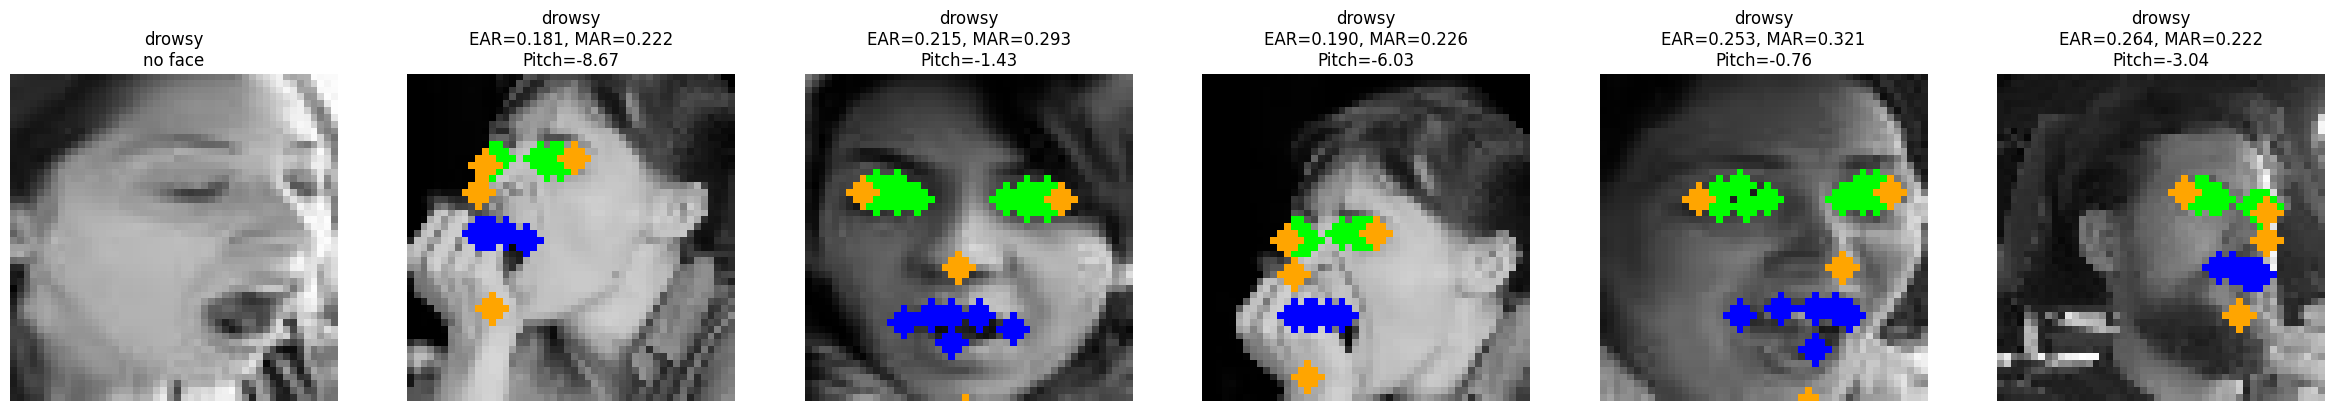

In [21]:
def draw_selected_landmarks(image_bgr: np.ndarray, points: np.ndarray) -> np.ndarray:
    """Draw the landmarks used by EAR, MAR, and head pitch."""
    annotated = image_bgr.copy()

    landmark_groups = {
        "eye": LEFT_EYE + RIGHT_EYE,
        "mouth": MOUTH,
        "pose": [NOSE_TIP, CHIN, LEFT_EYE_OUTER, RIGHT_EYE_OUTER],
    }
    colors = {
        "eye": (0, 255, 0),
        "mouth": (255, 0, 0),
        "pose": (0, 165, 255),
    }

    for group_name, indices in landmark_groups.items():
        for index in indices:
            x, y = points[index][:2].astype(int)
            cv2.circle(annotated, (x, y), 2, colors[group_name], -1)

    return annotated


def visualize_samples(image_label_pairs: List[Tuple[Path, str]], sample_count: int = 6) -> None:
    """Visualize a few successfully processed images with selected landmarks."""
    samples = image_label_pairs[:sample_count]

    if not samples:
        print("No images available for visualization.")
        return

    mp_face_mesh = mp.solutions.face_mesh
    figure, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4))

    if len(samples) == 1:
        axes = [axes]

    with mp_face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=0.5,
    ) as face_mesh:
        for axis, (image_path, label) in zip(axes, samples):
            image_bgr = load_image_bgr(image_path)

            if image_bgr is None:
                axis.set_title(f"{label}\nunreadable")
                axis.axis("off")
                continue

            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            results = face_mesh.process(image_rgb)

            if not results.multi_face_landmarks:
                axis.imshow(image_rgb)
                axis.set_title(f"{label}\nno face")
                axis.axis("off")
                continue

            points = normalized_landmarks_to_pixels(results.multi_face_landmarks[0], image_bgr.shape)
            annotated_bgr = draw_selected_landmarks(image_bgr, points)
            annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

            ear = calculate_ear(points)
            mar = calculate_mar(points)
            head_pitch = estimate_head_pitch(points)

            axis.imshow(annotated_rgb)
            axis.set_title(f"{label}\nEAR={ear:.3f}, MAR={mar:.3f}\nPitch={head_pitch:.2f}")
            axis.axis("off")

    plt.tight_layout()
    plt.show()


visualize_samples(image_label_pairs, sample_count=6)

## 9. Optional Failure Review

In [22]:
if failures_df.empty:
    print("No failed images recorded.")
else:
    display(failures_df.head(20))

,image_name,image_path,label,reason
0,1.jpg_0.png,c:\Users\chari\Desktop\AI_Powered_Fatigue_Dete...,drowsy,no_face_detected
1,1009.png,c:\Users\chari\Desktop\AI_Powered_Fatigue_Dete...,drowsy,no_face_detected
2,1013.png,c:\Users\chari\Desktop\AI_Powered_Fatigue_Dete...,drowsy,no_face_detected
3,111.jpg_0.png,c:\Users\chari\Desktop\AI_Powered_Fatigue_Dete...,drowsy,no_face_detected
4,112.jpg_0.png,c:\Users\chari\Desktop\AI_Powered_Fatigue_Dete...,drowsy,no_face_detected
5,1133.png,c:\Users\chari\Desktop\AI_Powered_Fatigue_Dete...,drowsy,no_face_detected
6,1134.png,c:\Users\chari\Desktop\AI_Powered_Fatigue_Dete...,drowsy,no_face_detected
7,114.jpg_0.png,c:\Users\chari\Desktop\AI_Powered_Fatigue_Dete...,drowsy,no_face_detected
8,115.jpg_0.png,c:\Users\chari\Desktop\AI_Powered_Fatigue_Dete...,drowsy,no_face_detected
9,1155.png,c:\Users\chari\Desktop\AI_Powered_Fatigue_Dete...,drowsy,no_face_detected


## Extension Notes

This dataset is intentionally image-level and feature-based. Later notebooks can build on the same structure for blink detection, PERCLOS, temporal windows, and LSTM-ready sequence datasets.